## 3.1. KMeans Clustering

In [ ]:
# Clustering - Kmeans - start with random partitioning of N elements into a set of K clusters, refine iteratively (flat algorithm) -> input: dataset, K value
# Hard clustering: each elemnt belongs to 1 cluster only
# Kmeans measure relatedness between vectors by EUCLIDEAN DISTANCE (equivalent to cosine similarity)
# Each cluster is defined by a centroid. The goal is to minimize the average squared distance from it by: reassignment (of vectors to their closest centroids) and recomputation (of the centroid as the average of its associated vectors)
# Kmeans is guaranteed to converge. The amount of iterations until that is unknown, although usually 10-20 is enough for a good enough take
# Convergence can get a poor result if the initial set of random centroids is unfortunate, so convergence != optimal clustering. Better options for computing initial centroids: some heuristic/ try multiple starting variations / results from another method like hierarchical clustering

In [ ]:
# Initialization of Kmeans
# Need to determine what K number of clusters

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import metrics

RANDOM_STATE = 10
DATA_PATH    = "data/processed/"

In [33]:
X  = np.load(DATA_PATH + "X_full_pca.npy") # must be numerical only TODO but as unsupervised, don't need test set STEP 1 IMPORT OUR DATA
# TODO need also corresponding labels to be predicted by the clusters y_full?

In [ ]:
# categorical features TODO STEP 2 SET OUR VARIABLES
df            = pd.read_csv(DATA_PATH + "df_reduced_out.csv")
cat_cols      = ["industry_primary", "country_hq", "attack_vector_primary"]
df_categories = df[cat_cols].reset_index(drop=True)

In [ ]:
# STEP 3 BUILDING THE CLUSTERING MODEL and CALCULATING DISTORTION AND INERTIA

distortions = []
inertias = []
mapping = {}
k_range = range(1, 10)

kmeans_per_k = [KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X) for k in k_range]

inertias     = [km.inertia_ for km in kmeans_per_k]


Inertia values:
k=1: 13653.34
k=2: 10268.01
k=3: 8541.86
k=4: 7310.40
k=5: 6527.48
k=6: 6187.65
k=7: 5812.61
k=8: 5459.17
k=9: 5223.67


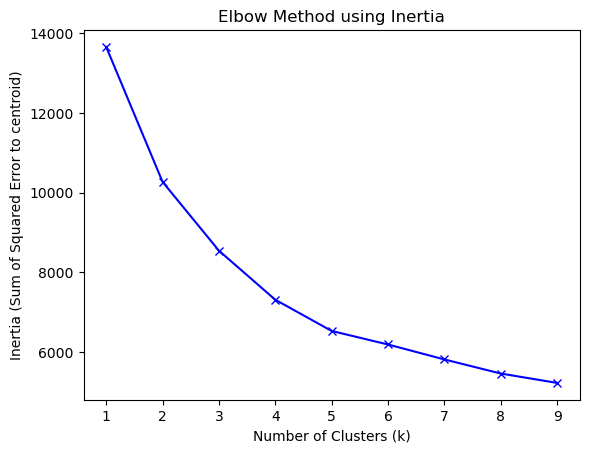

In [63]:
# STEP 4 Tabulating and Visualizing the Results

# Inertia — raw sum of squared distances to centroid, in the original units of your data. Hard to interpret the absolute value. SSE
# Inertia is the sum of squared distances from each data point to the center of its assigned cluster. It tells us how well the points are grouped in their clusters. The smaller the inertia the better the clustering.
# We plot the inertia for different values of K i.e different numbers of clusters. As K increases the inertia decrease because more clusters allow data points to be closer to their cluster centers.
# The goal is to find the value of K where the decrease in inertia starts to slow down. This is like an "elbow" in the plot where the curve bends and flattens out. The number of clusters at this point is considered the optimal value for K.
# Distortion — same concept as inertia but averaged per point - distortion = km.inertia_ / len(X)

print("Inertia values:")
for k, km in zip(k_range, kmeans_per_k):
    print(f"k={k}: {km.inertia_:.2f}")

plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Error to centroid)')
plt.title('Elbow Method using Inertia')
plt.show()

The graph shows a rather smooth curve than a clear elbow shape, meaning data is not that obviously grouped and/or is more continuous, so the data has no strong natural cluster structure.

We will use a second method to interpret the clustering of the data.

The silhouette method captures how similar each data point is to its own cluster compared to other clusters.
What is the silhouette score????????????????

k=2 : 0.6291
k=3 : 0.2002
k=4 : 0.2141
k=5 : 0.2192
k=6 : 0.1245
k=7 : 0.1077
k=8 : 0.1257
k=9 : 0.1160


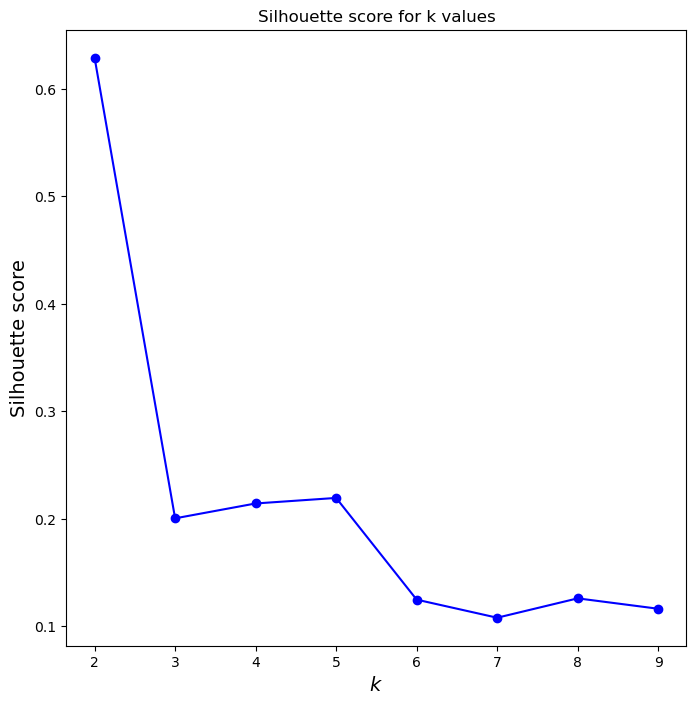

In [73]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in k_range]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]] # silhouette evaluates from k=2

for k, score in zip(list(k_range)[1:], silhouette_scores):
    print(f"k={k} : {score:.4f}")

plt.figure(figsize=(8,8))
plt.plot(list(k_range)[1:], silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title('Silhouette score for k values')
plt.show()

From both evaluations, we can determine k=2 is the stronger candidate, having a silhouette score that triples the next candidate, with a value of 0.6, which represents a reasonably meaningful cluster structure.

The rest of k divisions are under 0.5, reflecting weak or no meaningful cluster structure.

In [74]:
k = 2

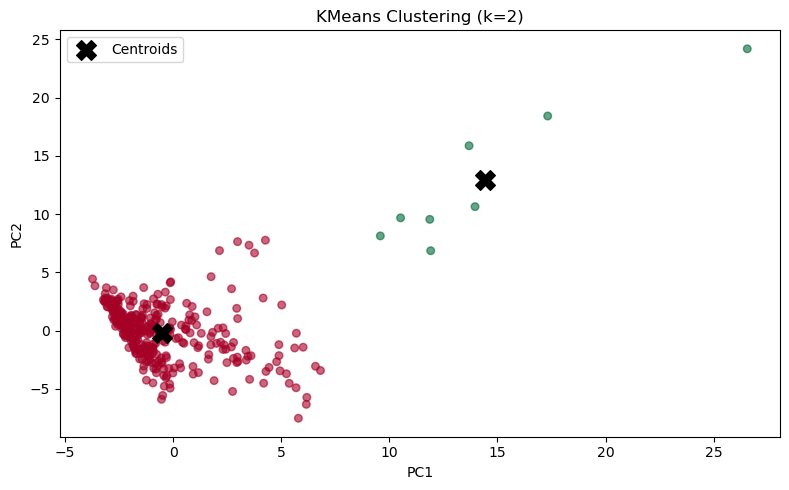

In [81]:
km = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
labels = km.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='RdYlGn', alpha=0.6, s=30)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title("KMeans Clustering (k=2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

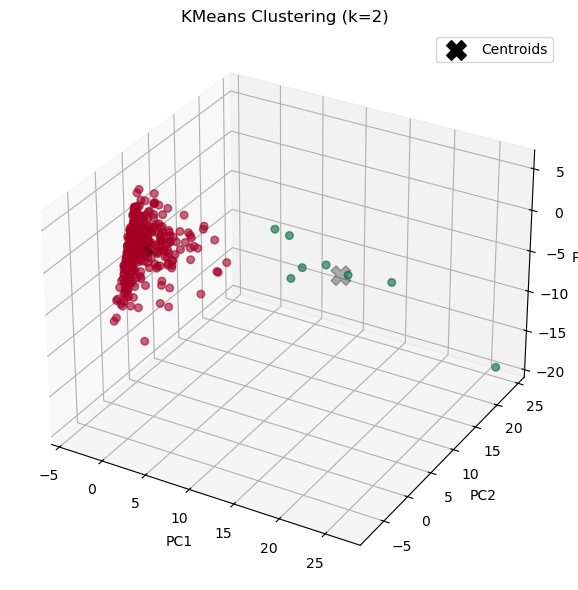

In [80]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='RdYlGn', alpha=0.6, s=30)
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], km.cluster_centers_[:, 2],
           c='black', marker='X', s=200, label='Centroids')

ax.set_title("KMeans Clustering (k=2)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend()
plt.tight_layout()
plt.show()

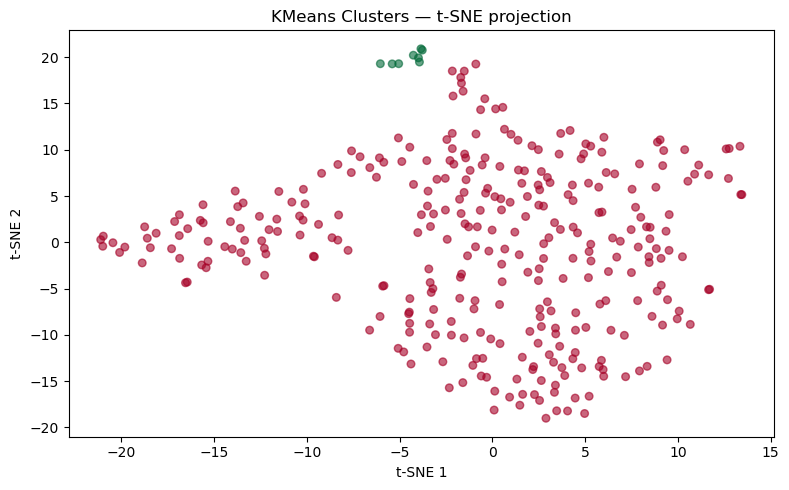

In [82]:
from sklearn.manifold import TSNE

tsne    = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne  = tsne.fit_transform(X)

plt.figure(figsize=(8, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='RdYlGn', alpha=0.6, s=30)
plt.title("KMeans Clusters — t-SNE projection")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

By inspection, it seems clusters correspond to a compact group and a group of outliers. We need to assess the clustering quality with respect to ground truth using labeled data.

In [84]:
# Intra-cluster similarity (compactness)

# Inertia — lower is better
print(f"Inertia: {km.inertia_:.2f}")

# Average distance to centroid per cluster
for i in range(2):
    cluster_points = X[labels == i]
    centroid        = km.cluster_centers_[i]
    avg_dist        = np.mean(np.linalg.norm(cluster_points - centroid, axis=1))
    print(f"Cluster {i} avg distance to centroid: {avg_dist:.4f}")

Inertia: 10268.01
Cluster 0 avg distance to centroid: 5.0385
Cluster 1 avg distance to centroid: 9.2798


In [83]:
# Inter-cluster similarity (separation)

# Distance between centroids — higher is better
from scipy.spatial.distance import euclidean
dist = euclidean(km.cluster_centers_[0], km.cluster_centers_[1])
print(f"Distance between centroids: {dist:.4f}")

Distance between centroids: 20.8258


In [85]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print(f"Silhouette        : {silhouette_score(X, labels):.4f}")       # higher better
print(f"Davies-Bouldin    : {davies_bouldin_score(X, labels):.4f}")   # lower better
print(f"Calinski-Harabasz : {calinski_harabasz_score(X, labels):.4f}")# higher better

Silhouette        : 0.6672
Davies-Bouldin    : 0.6875
Calinski-Harabasz : 107.8109


In [78]:
kmeans  = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
kmeans.fit(X)

centers          = kmeans.cluster_centers_  # shape: (2, 14)
y_full_clusters  = kmeans.predict(X)

print(f"Cluster sizes: {np.bincount(y_full_clusters)}")
print(f"Centers shape: {centers.shape}")

Cluster sizes: [75  5 46 47 96  9 47  1  3]
Centers shape: (9, 14)


k selection
  ├── Elbow (inertia)
  ├── Silhouette score per k
  └── Davies-Bouldin score per k

cluster quality
  ├── Silhouette plot per sample  ← shows within-cluster consistency
  └── Cluster size distribution  ← check for imbalanced clusters

cluster interpretation
  ├── Heatmap of feature means per cluster  ← name the clusters
  ├── Boxplots of key features per cluster  ← see spread within clusters
  └── PCA scatter (PC1 vs PC2) coloured by cluster  ← visual separation

cluster vs ground truth
  └── Crosstab of cluster label vs attack_vector_primary  ← do clusters align with attack types?